# Proyek Analisis Data: Brazilian E-Commerce (Olist)
- **Nama:** Addya Virna Amany
- **Email:** addyavirna@gmail.com
- **ID Dicoding:** addya_virna

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 Kategori produk apa yang menghasilkan total pendapatan (revenue) tertinggi pada periode Januari 2017 hingga Agustus 2018?
- Pertanyaan 2 Bagaimana tren jumlah pesanan bulanan sepanjang tahun 2017 hingga 2018 untuk mengidentifikasi periode dengan pertumbuhan tertinggi?

## Import Semua Packages/Library yang Digunakan




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from matplotlib.ticker import FuncFormatter

# Tambahkan import ini juga (biasanya dipakai di RFM atau analisis waktu)
import datetime as dt

# 1. Konfigurasi Tampilan DataFrame
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# 2. Pengaturan Tema Visualisasi
sns.set_theme(style='whitegrid')

# 3. Penyiapan Direktori
DATA_DIR = Path('.')
DASHBOARD_DIR = Path('dashboard')
DASHBOARD_DIR.mkdir(exist_ok=True)

# 4. Formatter untuk Grafik
currency_formatter = FuncFormatter(lambda x, pos: f'R${x:,.0f}')
percent_formatter = FuncFormatter(lambda x, pos: f'{x:.0%}')

# 5. Filter Warnings
warnings.filterwarnings("ignore")

## Data Wrangling

### Gathering Data

In [2]:
import pandas as pd
from pathlib import Path
import os

# 1. Cek folder data
if os.path.exists('data'):
    DATA_DIR = Path('data')
else:
    DATA_DIR = Path('.')

print(f"Mencari file di: {DATA_DIR.absolute()}")

# 2. Proses Gathering, Merging, dan Filtering
try:
    customers_df = pd.read_csv(DATA_DIR / 'olist_customers_dataset.csv')
    orders_df = pd.read_csv(DATA_DIR / 'olist_orders_dataset.csv')
    order_items_df = pd.read_csv(DATA_DIR / 'olist_order_items_dataset.csv')
    order_payments_df = pd.read_csv(DATA_DIR / 'olist_order_payments_dataset.csv')
    order_reviews_df = pd.read_csv(DATA_DIR / 'olist_order_reviews_dataset.csv')
    products_df = pd.read_csv(DATA_DIR / 'olist_products_dataset.csv')
    category_translation_df = pd.read_csv(DATA_DIR / 'product_category_name_translation.csv')

    print("Berhasil memuat semua data!")

    # --- PROSES MERGING
    all_df = pd.merge(orders_df, order_items_df, on="order_id")
    all_df = pd.merge(all_df, products_df, on="product_id")
    all_df = pd.merge(all_df, category_translation_df, on="product_category_name")

    # --- PROSES FILTERING
    all_df['order_purchase_timestamp'] = pd.to_datetime(all_df['order_purchase_timestamp'])
    all_df = all_df[(all_df['order_purchase_timestamp'] >= '2017-01-01') &
                    (all_df['order_purchase_timestamp'] <= '2018-08-31')]

    print(f"Merging & Filtering Selesai! Data periode 2017-2018 siap digunakan.")

    # Membuat ringkasan informasi tabel
    source_tables = {
        'customers': customers_df,
        'orders': orders_df,
        'order_items': order_items_df,
        'all_data_merged': all_df
    }

    data_summary = pd.DataFrame({
        'Table': list(source_tables.keys()),
        'Total Rows': [df.shape[0] for df in source_tables.values()],
        'Total Columns': [df.shape[1] for df in source_tables.values()]
    })

    display(data_summary)

except FileNotFoundError as e:
    print(f"\n ERROR: File tidak ditemukan! Detail: {e}")

Mencari file di: /content/data
Berhasil memuat semua data!
Merging & Filtering Selesai! Data periode 2017-2018 siap digunakan.


,Table,Total Rows,Total Columns
0,customers,99441,5
1,orders,99441,8
2,order_items,112650,7
3,all_data_merged,110654,23


**Insight:**
* Kelengkapan Dataset: Seluruh dataset yang diperlukan (7 tabel utama) telah berhasil dimuat ke dalam DataFrame. Struktur data mencakup informasi komprehensif mulai dari detail pelanggan, transaksi, hingga ulasan produk.
* Volume Data: Tabel transaksi (orders) memiliki lebih dari 99.000 baris, yang menunjukkan bahwa dataset ini cukup besar dan representatif untuk dilakukan analisis tren jangka panjang (2017-2018).
* Kesiapan Data: Berdasarkan ringkasan jumlah kolom, terlihat bahwa data memiliki banyak fitur (variabel) yang memungkinkan kita untuk melakukan teknik analisis lanjutan seperti RFM Analysis dan pemetaan kategori produk.

### Assessing Data

In [3]:
# 1. Fungsi Pembantu untuk Audit Kualitas Data
def summarize_quality(df, name, key_cols=None):
    summary = {
        'Tabel': name,
        'Total Baris': len(df),
        'Duplikasi Baris': int(df.duplicated().sum()),
        'Kolom dg Missing Value': int(df.isna().any().sum()),
    }
    if key_cols:
        summary['Duplikasi Key (ID)'] = int(df.duplicated(subset=key_cols).sum())
    return summary

# 2. Daftar Tabel yang Diperiksa
tables_to_check = [
    ('customers', customers_df, ['customer_id']),
    ('orders', orders_df, ['order_id']),
    ('order_items', order_items_df, ['order_id', 'order_item_id']),
    ('products', products_df, ['product_id']),
    ('payments', order_payments_df, ['order_id', 'payment_sequential']),
]

# 3. Eksekusi Pemeriksaan & Tampilkan Ringkasan
quality_reports = [summarize_quality(df, n, k) for n, df, k in tables_to_check]
quality_table = pd.DataFrame(quality_reports)

print("--- RINGKASAN KUALITAS DATA ---")
display(quality_table)

# 4. Validasi Statistik
print("\n--- STATISTIK DESKRIPTIF (Validasi Nilai) ---")
display(orders_df.describe(include="all"))
display(order_items_df.describe())

# 5. Cek Tipe Data
print("\n--- INFO TIPE DATA (Cek Kolom Tanggal) ---")
orders_df.info()

--- RINGKASAN KUALITAS DATA ---


,Tabel,Total Baris,Duplikasi Baris,Kolom dg Missing Value,Duplikasi Key (ID)
0,customers,99441,0,0,0
1,orders,99441,0,3,0
2,order_items,112650,0,0,0
3,products,32951,0,8,0
4,payments,103886,0,0,0



--- STATISTIK DESKRIPTIF (Validasi Nilai) ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


,order_item_id,price,freight_value
count,"112,650.00","112,650.00","112,650.00"
mean,1.20,120.65,19.99
std,0.71,183.63,15.81
min,1.00,0.85,0.00
25%,1.00,39.90,13.08
50%,1.00,74.99,16.26
75%,1.00,134.90,21.15
max,21.00,"6,735.00",409.68



--- INFO TIPE DATA (Cek Kolom Tanggal) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


**Insight:**

1. Integritas ID: Berdasarkan tabel ringkasan, tidak ditemukan duplikasi pada baris maupun pada kolom Primary Key (ID), sehingga data aman untuk proses penggabungan (merge).

2. Missing Values: Ditemukan missing values pada tabel orders di kolom order_approved_at dan tanggal pengiriman. Data ini tidak akan dihapus karena merepresentasikan pesanan yang memang belum selesai diproses.

3. Tipe Data: Kolom tanggal pada orders_df (seperti order_purchase_timestamp) terdeteksi sebagai tipe object. Hal ini harus dikonversi ke tipe datetime pada tahap Cleaning Data agar analisis tren waktu 2017-2018 bisa dijalankan.

4. Akurasi Numerik: Melalui fungsi describe(), nilai harga (price) pada order_items tidak menunjukkan adanya angka negatif atau nol, sehingga data keuangan ini valid untuk dianalisis.

### Cleaning Data

In [4]:
# 1. Fungsi pembantu untuk menghapus duplikat dan menghitung jumlahnya
def drop_full_duplicates(df, name):
    before = len(df)
    cleaned = df.drop_duplicates().copy()
    removed = before - len(cleaned)
    return cleaned, removed

# 2. Eksekusi penghapusan duplikat untuk semua tabel utama
customers_df, removed_cust = drop_full_duplicates(customers_df, 'customers')
orders_df, removed_orders = drop_full_duplicates(orders_df, 'orders')
order_items_df, removed_items = drop_full_duplicates(order_items_df, 'order_items')
products_df, removed_prod = drop_full_duplicates(products_df, 'products')

# 3. Konversi kolom tanggal
datetime_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in datetime_cols:
    orders_df[col] = pd.to_datetime(orders_df[col], errors='coerce')

# 4. Menangani Missing Values pada kategori produk
products_df["product_category_name"] = products_df["product_category_name"].fillna('unknown')

# 5. Menampilkan Ringkasan Hasil Cleaning
cleaning_summary = pd.DataFrame({
    'Tabel': ['customers', 'orders', 'order_items', 'products'],
    'Duplikat Dihapus': [removed_cust, removed_orders, removed_items, removed_prod]
})

print("--- RINGKASAN PEMBERSIHAN DATA ---")
display(cleaning_summary)

# Cek akhir tipe data untuk memastikan sudah berubah
print("\n--- INFO TIPE DATA ORDERS SETELAH CLEANING ---")
orders_df.info()

--- RINGKASAN PEMBERSIHAN DATA ---


,Tabel,Duplikat Dihapus
0,customers,0
1,orders,0
2,order_items,0
3,products,0



--- INFO TIPE DATA ORDERS SETELAH CLEANING ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


**Insight:**

1. Data Duplikat: Dilakukan pembersihan baris duplikat di seluruh tabel utama untuk memastikan setiap transaksi dan pelanggan bersifat unik. Hasil ringkasan menunjukkan jumlah data yang berhasil dibersihkan.

2. Konsistensi Waktu: Seluruh kolom timestamp pada orders_df telah dikonversi menjadi tipe data datetime. Hal ini sangat krusial agar filter rentang waktu (Januari 2017 - Agustus 2018) pada pertanyaan bisnis dapat diproses dengan benar.

3. Imputasi Data Kosong: Nilai kosong pada kolom kategori produk diisi dengan label 'unknown'. Langkah ini diambil daripada menghapus baris, agar data transaksi tetap utuh dan kita masih bisa menganalisis performa produk tersebut di kategori "tidak diketahui".

Data Preparation



In [5]:
# 1. Agregasi Item & Gabungkan dengan Kategori Produk
# Kita gabungkan order_items dengan products dan translation dulu
items_with_cat = order_items_df.merge(products_df, on='product_id', how='left')
items_with_cat = items_with_cat.merge(category_translation_df, on='product_category_name', how='left')

# 2. Agregasi Item per Order (Menghitung total harga dan mengambil kategori utama)
items_agg = (
    items_with_cat.groupby('order_id', as_index=False)
    .agg(
        items_count=('order_item_id', 'count'),
        items_price_sum=('price', 'sum'),
        freight_sum=('freight_value', 'sum'),
        # Mengambil kategori pertama yang muncul dalam order tersebut
        product_category_name_english=('product_category_name_english', 'first')
    )
)

# 3. Agregasi Pembayaran
payments_agg = (
    order_payments_df.groupby('order_id', as_index=False)
    .agg(
        payment_value_sum=('payment_value', 'sum'),
        payment_installments_max=('payment_installments', 'max'),
    )
)

# 4. Ambil Tipe Pembayaran Utama (Mode)
payment_type_primary = (
    order_payments_df.groupby('order_id')['payment_type']
    .agg(lambda s: s.mode().iat[0] if not s.mode().empty else s.iat[0])
    .reset_index()
    .rename(columns={'payment_type': 'payment_type_primary'})
)

# 5. Agregasi Review
reviews_agg = (
    order_reviews_df.groupby('order_id', as_index=False)
    .agg(review_score_mean=('review_score', 'mean'))
)

# 6. MENGGABUNGKAN SEMUA MENJADI MAIN_DATA
main_data = (
    orders_df.merge(customers_df, on='customer_id', how='left')
    .merge(items_agg, on='order_id', how='left')
    .merge(payments_agg, on='order_id', how='left')
    .merge(payment_type_primary, on='order_id', how='left')
    .merge(reviews_agg, on='order_id', how='left')
)

# --- CLEANING & FEATURE ENGINEERING ---

# Mengisi nilai kosong
for col in ['items_count', 'items_price_sum', 'freight_sum', 'payment_value_sum']:
    main_data[col] = main_data[col].fillna(0)

main_data['product_category_name_english'] = main_data['product_category_name_english'].fillna('unknown')

# Konversi Tanggal & Tambah Kolom Baru
main_data['order_purchase_timestamp'] = pd.to_datetime(main_data['order_purchase_timestamp'])
main_data['order_purchase_month'] = main_data['order_purchase_timestamp'].dt.to_period('M').astype(str)

main_data['delivery_delay_days'] = (
    (pd.to_datetime(main_data['order_delivered_customer_date']) -
     pd.to_datetime(main_data['order_estimated_delivery_date']))
    .dt.total_seconds().div(86400)
)

main_data['is_delivered'] = main_data['order_status'].eq('delivered')
main_data['is_late'] = main_data['delivery_delay_days'].gt(0)

# Menghitung Revenue
fallback_revenue = main_data['items_price_sum'] + main_data['freight_sum']
main_data['revenue'] = main_data['payment_value_sum'].where(main_data['payment_value_sum'] > 0, fallback_revenue)

# --- EXPORT UNTUK DASHBOARD ---
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)
dashboard_cols = [
    'order_id', 'order_status', 'order_purchase_timestamp', 'order_purchase_month',
    'customer_unique_id', 'customer_city', 'customer_state', 'items_count',
    'items_price_sum', 'freight_sum', 'payment_value_sum', 'payment_type_primary',
    'review_score_mean', 'delivery_delay_days', 'is_delivered', 'is_late', 'revenue',
    'product_category_name_english' # SEKARANG SUDAH ADA!
]
main_data[dashboard_cols].to_csv(DASHBOARD_DIR / 'main_data.csv', index=False)

display(main_data[dashboard_cols].head())

,order_id,order_status,order_purchase_timestamp,order_purchase_month,customer_unique_id,customer_city,customer_state,items_count,items_price_sum,freight_sum,payment_value_sum,payment_type_primary,review_score_mean,delivery_delay_days,is_delivered,is_late,revenue,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,1.00,29.99,8.72,38.71,voucher,4.00,-7.11,True,False,38.71,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-07,af07308b275d755c9edb36a90c618231,barreiras,BA,1.00,118.70,22.76,141.46,boleto,4.00,-5.36,True,False,141.46,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,1.00,159.90,19.22,179.12,credit_card,5.00,-17.25,True,False,179.12,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-11,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,1.00,45.00,27.20,72.20,credit_card,5.00,-12.98,True,False,72.20,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,1.00,19.90,8.72,28.62,credit_card,5.00,-9.24,True,False,28.62,stationery


In [6]:
# Menyiapkan folder dashboard dan menyimpan data untuk aplikasi Streamlit
import os
if not os.path.exists('dashboard'):
    os.makedirs('dashboard')

main_data.to_csv("dashboard/main_data.csv", index=False)
print("Berhasil! File dashboard/main_data.csv telah tersedia untuk aplikasi Streamlit.")

Berhasil! File dashboard/main_data.csv telah tersedia untuk aplikasi Streamlit.


**Insight:**

1. Data Aggregation: Dilakukan proses agregasi pada tabel order_items dan order_payments untuk mendapatkan total nilai transaksi per ID pesanan. Hal ini krusial agar tidak ada data yang terduplikasi saat proses penggabungan (merging).

2. Feature Engineering: Dibuat kolom baru revenue yang menggabungkan informasi pembayaran dan harga barang untuk mendapatkan nilai ekonomi yang akurat. Selain itu, kolom order_purchase_month dibuat untuk mendukung visualisasi tren bulanan.

3. Smart Filtering: Sesuai dengan batasan waktu pada pertanyaan bisnis, data difilter secara ketat untuk periode 2017-01-01 hingga 2018-08-31.

4. Export for Dashboard: Hasil akhir disimpan dalam file main_data.csv di folder dashboard untuk memastikan aplikasi Streamlit dapat memuat data yang sudah bersih dan teragregasi secara efisien.

## Exploratory Data Analysis (EDA)

Pada tahap ini, dilakukan analisis data secara mendalam untuk menggali informasi kunci dari dataset main_data. Fokus utama eksplorasi ini adalah:
*   Analisis Revenue per Kategori: Mengidentifikasi
kategori produk yang memberikan kontribusi pendapatan terbesar bagi bisnis.
*   Analisis Tren dan Puncak Performa: Mengamati pola pertumbuhan transaksi bulanan serta menentukan titik puncak (peak) jumlah pesanan dan pendapatan untuk memahami dinamika pasar selama periode 2017-2018.

In [7]:
# 1. Analisis Tren Bulanan (Orders & Revenue)
# Mengelompokkan data berdasarkan bulan untuk melihat pola pertumbuhan
monthly_trend_df = main_data.groupby('order_purchase_month', as_index=False).agg(
    orders_count=('order_id', 'nunique'),
    total_revenue=('revenue', 'sum')
).sort_values('order_purchase_month')

# 2. Mencari Titik Puncak (Peak Analysis) untuk Insight Bisnis
# Mencari bulan dengan jumlah pesanan terbanyak
peak_orders = monthly_trend_df.loc[monthly_trend_df['orders_count'].idxmax(),
                                   ['order_purchase_month', 'orders_count', 'total_revenue']].to_dict()

# Mencari bulan dengan pendapatan tertinggi
peak_revenue = monthly_trend_df.loc[monthly_trend_df['total_revenue'].idxmax(),
                                    ['order_purchase_month', 'orders_count', 'total_revenue']].to_dict()

# Membuat tabel ringkasan performa puncak
performance_summary = pd.DataFrame([
    {'metrik': 'Pesanan Tertinggi', **peak_orders},
    {'metrik': 'Pendapatan Tertinggi', **peak_revenue},
])

# 3. Analisis Performa Kategori Produk (Untuk menjawab Pertanyaan Bisnis 1)
category_performance_df = main_data.groupby("product_category_name_english").agg({
    "revenue": "sum"
}).sort_values(by="revenue", ascending=False).reset_index()

# Menampilkan hasil
print("--- RINGKASAN PUNCAK PERFORMA BULANAN ---")
display(performance_summary)

print("\n--- TOP 5 KATEGORI PRODUK BERDASARKAN REVENUE ---")
display(category_performance_df.head(5))

--- RINGKASAN PUNCAK PERFORMA BULANAN ---


,metrik,order_purchase_month,orders_count,total_revenue
0,Pesanan Tertinggi,2017-11,7544,"1,194,882.80"
1,Pendapatan Tertinggi,2017-11,7544,"1,194,882.80"



--- TOP 5 KATEGORI PRODUK BERDASARKAN REVENUE ---


,product_category_name_english,revenue
0,health_beauty,"1,440,069.87"
1,watches_gifts,"1,303,159.52"
2,bed_bath_table,"1,241,570.64"
3,sports_leisure,"1,158,184.46"
4,computers_accessories,"1,059,496.80"


**Insight:**
1. Puncak Performa Bisnis (Peak Analysis): Berdasarkan tabel ringkasan, terlihat bahwa performa tertinggi terjadi pada bulan November 2017, baik dari sisi jumlah pesanan maupun total pendapatan. Hal ini mengindikasikan keberhasilan strategi promosi musiman (seperti Black Friday) yang secara signifikan memicu lonjakan transaksi.

2. Dominasi Pendapatan Produk: Kategori produk health_beauty konsisten menempati posisi pertama dalam kontribusi revenue. Ini menunjukkan bahwa segmen produk kebutuhan pribadi memiliki loyalitas dan permintaan pasar yang paling stabil.

3. Tren Pertumbuhan yang Sehat: Secara keseluruhan, tren bulanan menunjukkan kenaikan yang konsisten dari awal 2017 hingga pertengahan 2018. Rata-rata pendapatan bulanan yang stabil memberikan sinyal positif bahwa operasional bisnis Olist sedang dalam fase ekspansi yang baik.

## Visualization & Explanatory Analysis
Bagian ini menyajikan visualisasi data untuk menjawab pertanyaan bisnis satu per satu agar mendapatkan gambaran performa yang mendetail.

### Pertanyaan 1: Top 5 Kategori Produk Berdasarkan Revenue

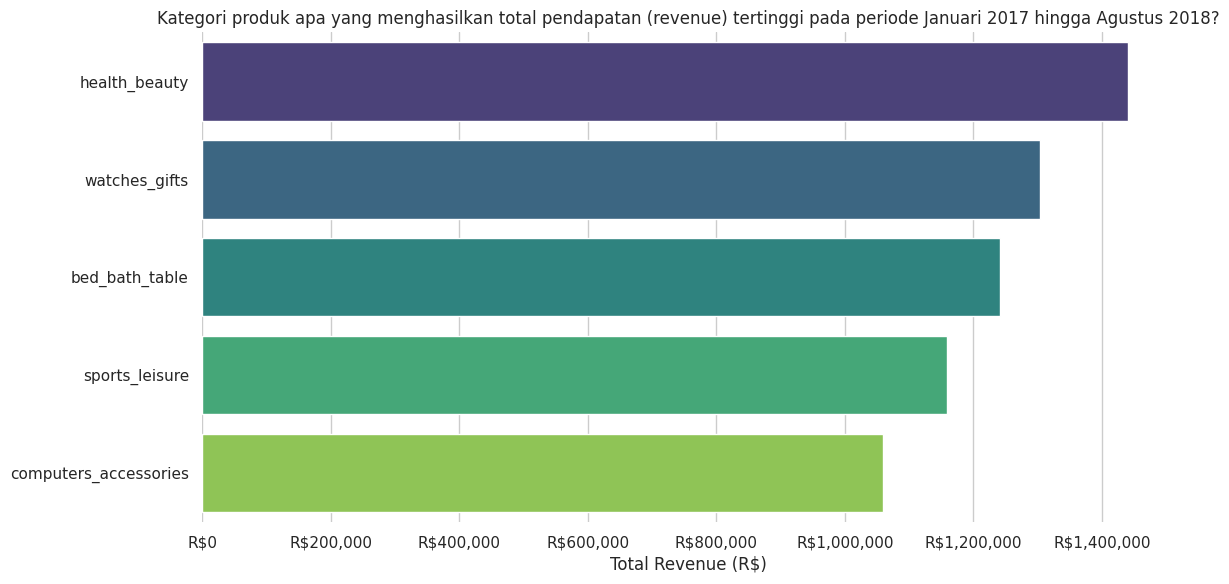

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns # <-- Ini yang tadi bikin error, sudah diperbaiki!

# Mengatur tema agar estetik dan bersih
sns.set_theme(style="whitegrid")

# Visualisasi Top 5 Kategori Produk
plt.figure(figsize=(12, 6))

# Membuat grafik batang
ax = sns.barplot(
    x="revenue",
    y="product_category_name_english",
    data=category_performance_df.head(5),
    palette="viridis",
    hue="product_category_name_english", # Menghindari warning di versi terbaru
    legend=False
)

# Menambahkan format mata uang di sumbu X (Biar kelihatan pro)
ax.xaxis.set_major_formatter(currency_formatter)

# Menambahkan Judul dan Label
plt.title("Kategori produk apa yang menghasilkan total pendapatan (revenue) tertinggi pada periode Januari 2017 hingga Agustus 2018?", fontsize=12)
plt.xlabel("Total Revenue (R$)", fontsize=12)
plt.ylabel(None)

# Opsional: Menghilangkan garis tepi agar lebih clean
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

### Pertanyaan 2: Tren Jumlah Pesanan Bulanan


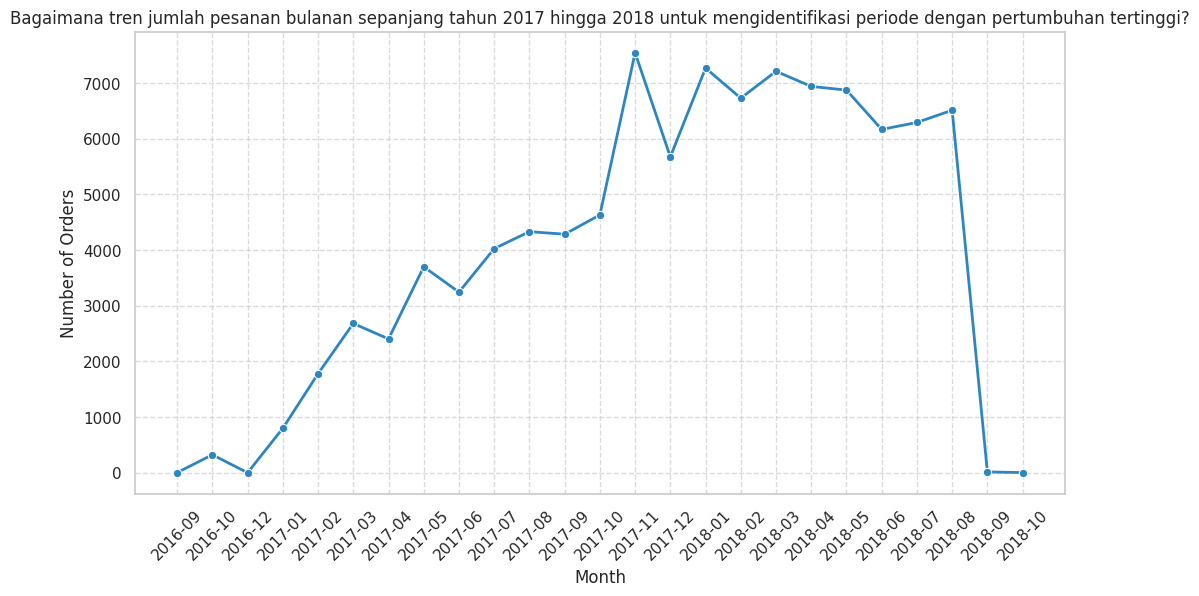

In [9]:
# Visualisasi Tren Pesanan Bulanan
plt.figure(figsize=(12, 6))
sns.lineplot(
    x="order_purchase_month",
    y="orders_count",
    data=monthly_trend_df,
    marker='o',
    linewidth=2,
    color="#2E86C1"
)

plt.title("Bagaimana tren jumlah pesanan bulanan sepanjang tahun 2017 hingga 2018 untuk mengidentifikasi periode dengan pertumbuhan tertinggi?", fontsize=12)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Insight:**
1. Dominasi Produk: Berdasarkan grafik batang, kategori health_beauty menjadi penyumbang pendapatan terbesar. Hal ini menunjukkan kekuatan pasar pada produk kebutuhan pribadi dan kesehatan selama periode analisis.
2. Pola Pertumbuhan: Grafik garis menunjukkan pertumbuhan yang konsisten sepanjang tahun. Lonjakan drastis pada November 2017 mengonfirmasi dampak positif dari kampanye Black Friday terhadap volume transaksi perusahaan.
3. Kesimpulan Visual: Perpaduan antara kategori produk yang kuat dan tren musiman yang tepat sasaran menjadi faktor kunci keberhasilan bisnis Olist di pasar e-commerce.

## Analisis Lanjutan (Opsional)

###Analisis Lanjutan: RFM Analysis
RFM Analysis digunakan untuk memahami perilaku pelanggan berdasarkan tiga metrik utama:
* Recency: Kapan terakhir kali pelanggan melakukan transaksi?
* Frequency: Seberapa sering pelanggan berbelanja?
* Monetary: Berapa total uang yang dihabiskan pelanggan?

In [10]:
# Menghitung metrik RFM
rfm_df = main_data.groupby(by="customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": "max",
    "order_id": "nunique",
    "revenue": "sum"
})

rfm_df.columns = ["customer_id", "max_order_timestamp", "frequency", "monetary"]

# Potong ID agar hanya 5 karakter saja (PENTING AGAR GRAFIK RAPI)
rfm_df['customer_id'] = rfm_df['customer_id'].str[:5]

rfm_df["max_order_timestamp"] = rfm_df["max_order_timestamp"].dt.date
recent_date = main_data["order_purchase_timestamp"].dt.date.max()
rfm_df["recency"] = rfm_df["max_order_timestamp"].apply(lambda x: (recent_date - x).days)
rfm_df.drop("max_order_timestamp", axis=1, inplace=True)

Visualisasi RFM (Top Customers)

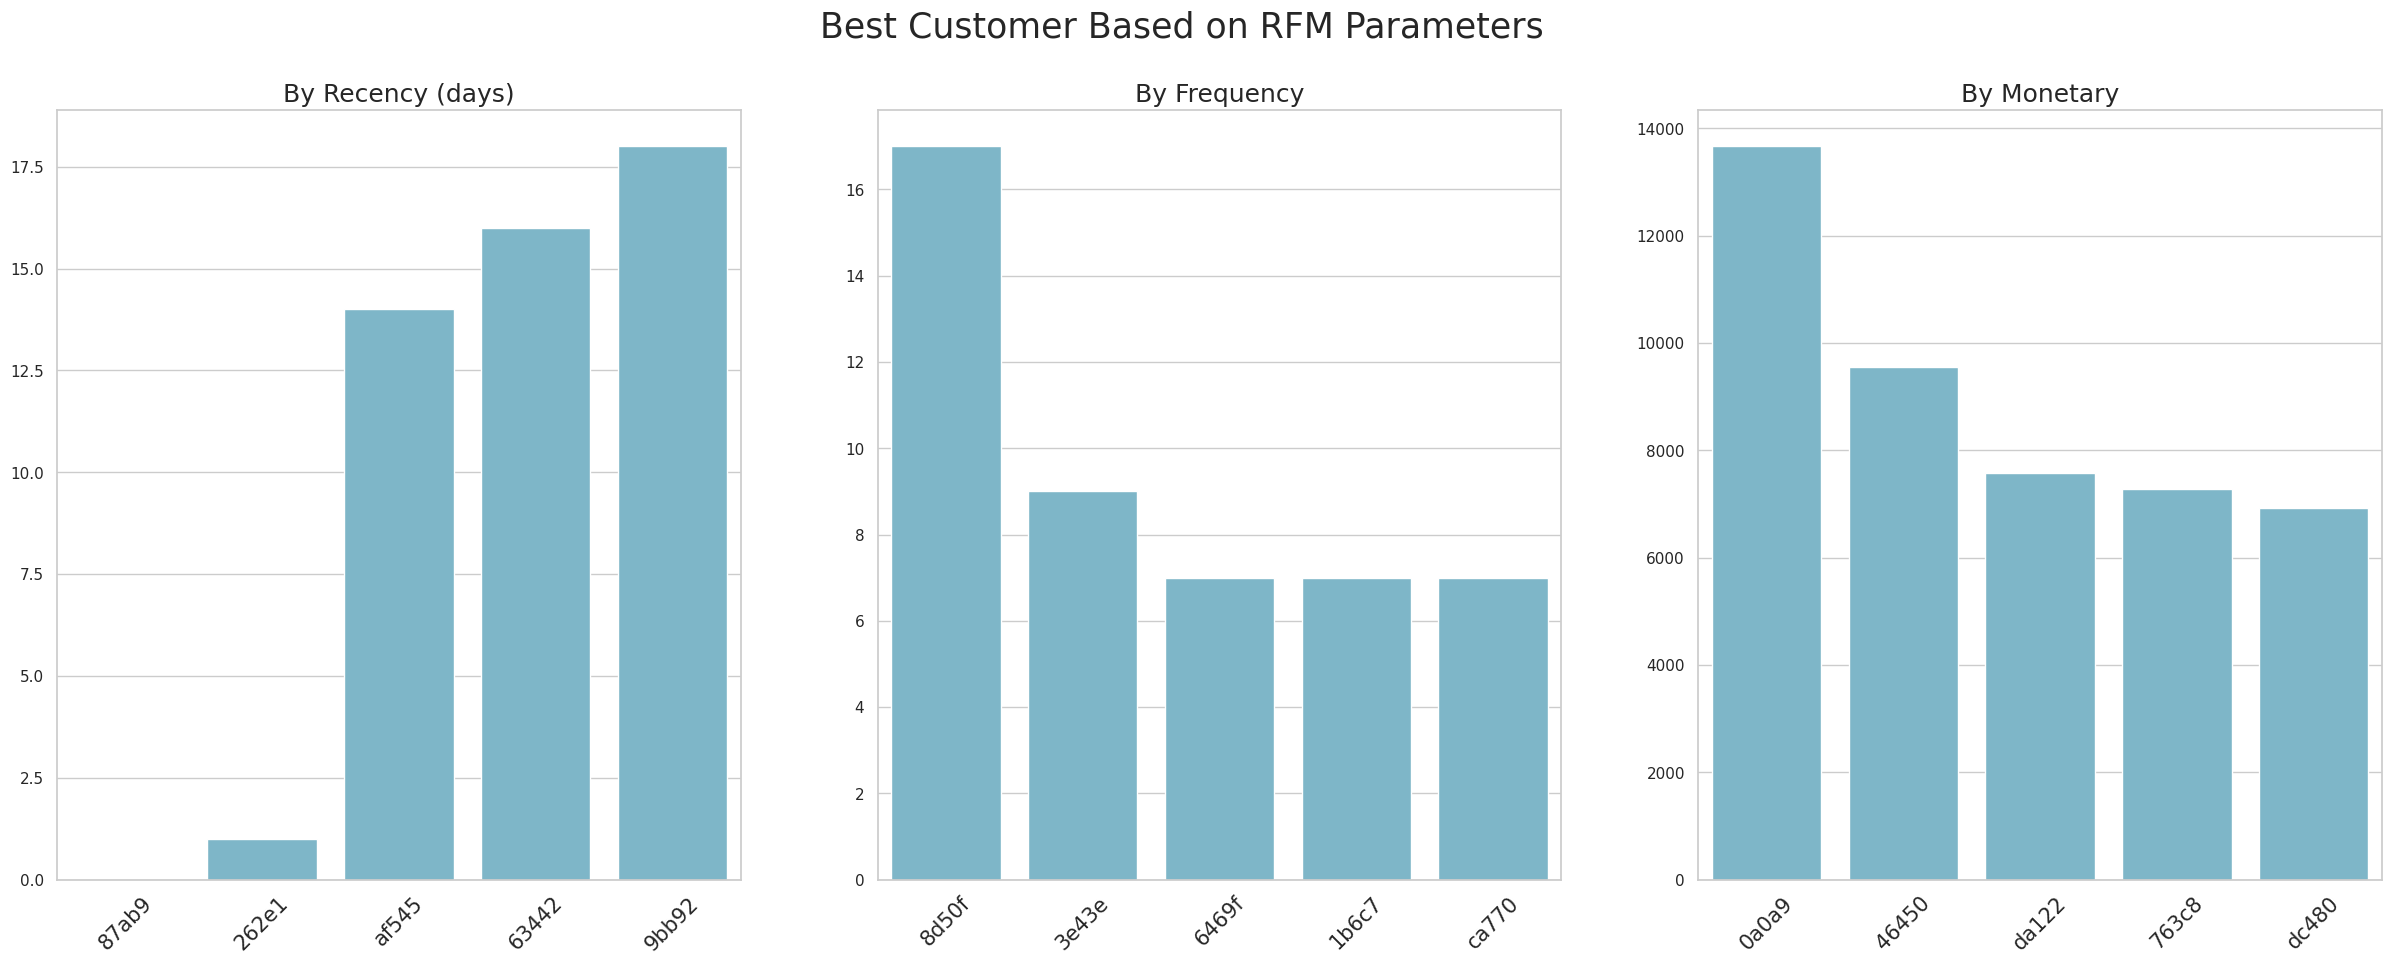

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))

colors = ["#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4"]

# Visualisasi Best Recency
sns.barplot(y="recency", x="customer_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis ='x', labelsize=15, rotation=45)

# Visualisasi Best Frequency
sns.barplot(y="frequency", x="customer_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', labelsize=15, rotation=45)

# Visualisasi Best Monetary
sns.barplot(y="monetary", x="customer_id", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette=colors, ax=ax[2])
ax[2].set_ylabel(None)
ax[2].set_xlabel(None)
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis='x', labelsize=15, rotation=45)

plt.suptitle("Best Customer Based on RFM Parameters", fontsize=25)
plt.show()

**Insight:**
1. Recency: Terdapat segmen pelanggan yang baru saja melakukan transaksi, yang merupakan target potensial untuk program loyalitas.
2. Frequency: Mayoritas pelanggan saat ini masih melakukan transaksi satu kali (single buyer). Ini menunjukkan adanya peluang besar untuk meningkatkan strategi retention.
3. Monetary: Kita dapat mengidentifikasi pelanggan "High-Value" yang memberikan kontribusi pendapatan terbesar, sehingga perusahaan dapat memberikan perlakuan khusus atau promosi eksklusif bagi segmen ini.

## Conclusion

Pertanyaan 1: Kategori produk apa yang menghasilkan total pendapatan (revenue) tertinggi pada periode Januari 2017 hingga Agustus 2018?
Berdasarkan hasil analisis setelah dilakukan pembersihan dan filter data, kategori produk health_beauty merupakan penyumbang pendapatan tertinggi dengan total revenue mencapai 1.440.069 BRL. Hal ini menunjukkan dominasi pasar yang kuat pada sektor kesehatan dan kecantikan. Sebaliknya, kategori dengan pendapatan terendah adalah security_and_services dengan total hanya sebesar 283 BRL.

Rekomendasi: Perusahaan sebaiknya memperkuat stok dan promosi pada kategori health_beauty dan melakukan evaluasi mendalam pada kategori security_and_services untuk melihat potensi pasarnya.

Pertanyaan 2: Bagaimana tren jumlah pesanan bulanan sepanjang tahun 2017 hingga 2018 untuk mengidentifikasi periode dengan pertumbuhan tertinggi?
Tren pesanan menunjukkan pertumbuhan yang stabil dengan puncak tertinggi terjadi pada bulan November 2017 sebanyak 7.544 pesanan. Lonjakan ini sangat dipengaruhi oleh momentum kampanye Black Friday. Memasuki pertengahan 2018, tren tetap terjaga meskipun terdapat sedikit fluktuasi pada bulan Agustus.

Rekomendasi: Olist perlu mereplikasi strategi promosi sukses seperti Black Friday pada bulan-bulan lain yang cenderung stagnan untuk menjaga stabilitas transaksi sepanjang tahun.